# 09 — Multi-Dataset Training

**Goal:** Train the MLP on a combined dataset of all available domains (CelebDF + FaceForensics++ + Stable Diffusion) to improve cross-domain generalisation.

**Problem being fixed:** The current pipeline trains only on CelebDF, producing FF++ cross-dataset AUC of 0.6391. By exposing the MLP to multiple source distributions simultaneously, it is forced to learn features stable across generators rather than CelebDF-specific artefacts.

**Implementation plan:**
1. Load `Z_celebdf.npy`, `Z_ff.npy`, `Z_sd.npy` and their labels
2. Concatenate into `Z_multi` / `y_multi` (~222k samples)
3. 70 / 15 / 15 stratified train/val/test split
4. Train `MLPTrainer` on the combined splits (checkpoint: `mlp_multi_best.pt`)
5. Evaluate on `Z_test_multi` and cross-dataset splits
6. Plot and save training curves to `results/mlp_multi_training_curve.png`

**Expected dataset size:** CelebDF (54,133) + FF++ (159,051) + SD (9,000) = **222,184** images  
**Class balance:** Real ~25.4% (56,405) / Fake ~74.6% (165,779)  
**Feature dim:** 981 (stat=4 + freq=2 + wavelet=200 + CNN=512 + ext=263)

In [1]:
import sys, numpy as np, time
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split

sys.path.insert(0, '/data/mpstme-naman/deepfake_detection')

BASE     = Path('/data/mpstme-naman/deepfake_detection')
FEAT_DIR = BASE / 'data' / 'features'
CKPT_DIR = BASE / 'checkpoints'
RES_DIR  = BASE / 'results'; RES_DIR.mkdir(parents=True, exist_ok=True)

from config.config_loader      import load_config
from src.models.mlp_classifier import MLPTrainer

cfg = load_config()
print('  Paths and imports ready.')
print(f'  FEAT_DIR : {FEAT_DIR}')
print(f'  CKPT_DIR : {CKPT_DIR}')

  Paths and imports ready.
  FEAT_DIR : /data/mpstme-naman/deepfake_detection/data/features
  CKPT_DIR : /data/mpstme-naman/deepfake_detection/checkpoints


## Step 1 — Load Feature Matrices

In [2]:
# Load all three datasets (981-dim, produced by fix_pipeline_state.py)
print('Loading feature matrices...')
print()

Z_celebdf = np.load(FEAT_DIR / 'Z_celebdf.npy').astype(np.float32)
y_celebdf = np.load(FEAT_DIR / 'y_celebdf.npy').astype(np.int64)

Z_ff      = np.load(FEAT_DIR / 'Z_ff.npy').astype(np.float32)
y_ff      = np.load(FEAT_DIR / 'y_ff.npy').astype(np.int64)

Z_sd      = np.load(FEAT_DIR / 'Z_sd.npy').astype(np.float32)
y_sd      = np.load(FEAT_DIR / 'y_sd.npy').astype(np.int64)

for name, Z, y in [('CelebDF',         Z_celebdf, y_celebdf),
                   ('FaceForensics++',  Z_ff,      y_ff),
                   ('Stable Diffusion', Z_sd,      y_sd)]:
    print(f'  {name:<20}  shape={str(Z.shape):<16}  '
          f'real={int((y==0).sum()):>6,}  fake={int((y==1).sum()):>7,}')

print()
print(f'  Feature dim : {Z_celebdf.shape[1]}  (981-dim pipeline)')
assert Z_celebdf.shape[1] == Z_ff.shape[1] == Z_sd.shape[1], \
    'Feature dims do not match — re-run fix_pipeline_state.py first'
print(f'  Dim check   : PASSED')

Loading feature matrices...

  CelebDF               shape=(54133, 981)      real=29,097  fake= 25,036
  FaceForensics++       shape=(159051, 981)     real=27,308  fake=131,743
  Stable Diffusion      shape=(9000, 981)       real=     0  fake=  9,000

  Feature dim : 981  (981-dim pipeline)
  Dim check   : PASSED


## Step 2 — Combine Datasets

In [3]:
Z_multi = np.concatenate([Z_celebdf, Z_ff, Z_sd], axis=0)
y_multi = np.concatenate([y_celebdf, y_ff, y_sd], axis=0)

n_real  = int((y_multi == 0).sum())
n_fake  = int((y_multi == 1).sum())
n_total = len(y_multi)

print('Combined multi-dataset:')
print(f'  Total samples : {n_total:,}  ({n_total/1000:.1f}k)')
print(f'  Real          : {n_real:,}  ({n_real/n_total*100:.1f}%)')
print(f'  Fake          : {n_fake:,}  ({n_fake/n_total*100:.1f}%)')
print(f'  Imbalance     : 1 : {n_fake/n_real:.2f}  (fake/real)')
print(f'  Feature dim   : {Z_multi.shape[1]}')

# pos_weight for BCE loss (passed to MLPTrainer to down-weight majority class)
pos_weight_value = round(n_real / n_fake, 4)
print(f'  pos_weight    : {pos_weight_value}  (BCEWithLogitsLoss weight on fake class)')

Combined multi-dataset:
  Total samples : 222,184  (222.2k)
  Real          : 56,405  (25.4%)
  Fake          : 165,779  (74.6%)
  Imbalance     : 1 : 2.94  (fake/real)
  Feature dim   : 981
  pos_weight    : 0.3402  (BCEWithLogitsLoss weight on fake class)


## Step 3 — Stratified 70 / 15 / 15 Split

`stratify=y_multi` preserves the ~25% real / ~75% fake ratio in every split.

In [4]:
# First split: 70% train, 30% temp
Z_train_multi, Z_tmp, y_train_multi, y_tmp = train_test_split(
    Z_multi, y_multi,
    test_size=0.30,
    random_state=42,
    stratify=y_multi
)

# Second split: 50% of remaining → val / test  (= 15% / 15% overall)
Z_val_multi, Z_test_multi, y_val_multi, y_test_multi = train_test_split(
    Z_tmp, y_tmp,
    test_size=0.50,
    random_state=42,
    stratify=y_tmp
)

print('Multi-dataset splits:')
print()
for split_name, Z, y in [
    ('Train (70%)', Z_train_multi, y_train_multi),
    ('Val   (15%)', Z_val_multi,   y_val_multi),
    ('Test  (15%)', Z_test_multi,  y_test_multi),
]:
    r = int((y==0).sum()); f = int((y==1).sum())
    print(f'  {split_name}  N={len(y):>7,}  '
          f'real={r:>6,} ({r/len(y)*100:.1f}%)  '
          f'fake={f:>7,} ({f/len(y)*100:.1f}%)')

# Save splits for reproducibility and downstream notebooks
print()
print('Saving splits...')
for arr_name, arr in [
    ('Z_train_multi', Z_train_multi), ('y_train_multi', y_train_multi),
    ('Z_val_multi',   Z_val_multi),   ('y_val_multi',   y_val_multi),
    ('Z_test_multi',  Z_test_multi),  ('y_test_multi',  y_test_multi),
]:
    p = FEAT_DIR / f'{arr_name}.npy'
    np.save(p, arr)
    print(f'  {p.name:<32}  {p.stat().st_size/1e6:.1f} MB')

Multi-dataset splits:

  Train (70%)  N=155,528  real=39,483 (25.4%)  fake=116,045 (74.6%)
  Val   (15%)  N= 33,328  real= 8,461 (25.4%)  fake= 24,867 (74.6%)
  Test  (15%)  N= 33,328  real= 8,461 (25.4%)  fake= 24,867 (74.6%)

Saving splits...
  Z_train_multi.npy                 610.3 MB
  y_train_multi.npy                 1.2 MB
  Z_val_multi.npy                   130.8 MB
  y_val_multi.npy                   0.3 MB
  Z_test_multi.npy                  130.8 MB
  y_test_multi.npy                  0.3 MB


## Step 4 — Initialise MLPTrainer

In [5]:
input_dim = Z_train_multi.shape[1]  # 981

# Import fixed MultiDatasetTrainer
# NOTE: Use MLPTrainer directly — it already has WeightedRandomSampler for imbalance.
# MultiDatasetTrainer adds pos_weight support (correct convention: > 1 UP-weights fakes)
# use_dann=True is disabled — requires proper Gradient Reversal implementation.
from src.models.mlp_classifier import MLPTrainer

mlp_multi = MLPTrainer(
    cfg       = cfg,
    input_dim = input_dim,
)

print('MLPTrainer initialised (WeightedRandomSampler handles 1:2.94 imbalance):')
print(f'  input_dim  : {input_dim}')
print(f'  hidden     : {mlp_multi._hidden_dim}')
print(f'  dropout    : {mlp_multi._dropout}')
print(f'  lr         : {mlp_multi._lr}')
print(f'  n_epochs   : {mlp_multi._epochs}')
print(f'  batch_size : {mlp_multi._batch_size}')
print(f'  device     : {mlp_multi._device}')
print()
print('Class imbalance handled by: WeightedRandomSampler (base class)')
print(f'  n_real={int((y_train_multi==0).sum()):,}  n_fake={int((y_train_multi==1).sum()):,}')
print(f'  sampler weights: w_real=2.94x  w_fake=1.00x  (balanced per-batch sampling)')

MLPTrainer initialised (WeightedRandomSampler handles 1:2.94 imbalance):
  input_dim  : 981
  hidden     : 256
  dropout    : 0.3
  lr         : 0.0001
  n_epochs   : 50
  batch_size : 32
  device     : cuda

Class imbalance handled by: WeightedRandomSampler (base class)
  n_real=39,483  n_fake=116,045
  sampler weights: w_real=2.94x  w_fake=1.00x  (balanced per-batch sampling)


## Step 5 — Train on Multi-Dataset Splits

The model is saved to `checkpoints/mlp_multi_best.pt` whenever validation AUC improves.  
Training uses the same `MLPTrainer` as NB03 — no code changes needed.

In [6]:
ckpt_dir = str(CKPT_DIR)

print(f'Training on {len(y_train_multi):,} samples → {CKPT_DIR}/mlp_multi_best.pt')
print(f'Class imbalance: handled by WeightedRandomSampler (no pos_weight needed)')
print()

t0 = time.time()

best_auc = mlp_multi.train(
    X_train         = Z_train_multi,
    y_train         = y_train_multi,
    X_val           = Z_val_multi,
    y_val           = y_val_multi,
    checkpoint_dir  = ckpt_dir,
    run_name        = 'mlp_multi',
)

elapsed = time.time() - t0
print(f'\n  Training complete in {elapsed/60:.1f} min')
print(f'  Best checkpoint saved → {CKPT_DIR}/mlp_multi_best.pt')

Training on 155,528 samples → /data/mpstme-naman/deepfake_detection/checkpoints/mlp_multi_best.pt
Class imbalance: handled by WeightedRandomSampler (no pos_weight needed)


  MLP Training  [981-dim → 256 → 64 → 1]
  Device: cuda   Epochs: 50   Batch: 32
  Train: 155528   Val: 33328
   Epoch    T-Loss    V-Loss    T-Acc    V-Acc    V-AUC
  -------------------------------------------------------
       1    0.3976    0.3050    80.8%    86.3%   0.947  ← best
       2    0.2781    0.2292    87.8%    90.5%   0.965  ← best
       3    0.2334    0.2039    90.1%    91.5%   0.973  ← best
       4    0.2062    0.1913    91.3%    92.0%   0.974  ← best
       5    0.1850    0.1765    92.4%    92.8%   0.979  ← best
       6    0.1702    0.1653    93.1%    93.2%   0.981  ← best
       7    0.1588    0.1879    93.6%    91.9%   0.981
       8    0.1467    0.1553    94.1%    93.6%   0.983  ← best
       9    0.1371    0.1543    94.5%    93.8%   0.985  ← best
      10    0.1296    0.1562    94.8%    93.

## Step 6 — Evaluation

Evaluate on the multi-dataset test split **and** on the individual held-out dataset splits to measure cross-domain improvement directly against the NB03 baseline.

In [7]:
from sklearn.metrics import (accuracy_score, roc_auc_score,
                              f1_score, precision_score, recall_score,
                              confusion_matrix)

def evaluate(Z, y, label, baseline_auc=None):
    probs = mlp_multi.predict_proba(Z)
    preds = (probs >= 0.5).astype(int)
    acc   = accuracy_score(y, preds) * 100
    auc   = roc_auc_score(y, probs) if len(np.unique(y)) > 1 else float('nan')
    f1    = f1_score(y, preds, zero_division=0)
    prec  = precision_score(y, preds, zero_division=0)
    rec   = recall_score(y, preds, zero_division=0)
    delta = f'  delta={auc - baseline_auc:+.4f}' if baseline_auc else ''
    print(f'  {label}:')
    print(f'    ACC={acc:.2f}%  AUC={auc:.4f}{delta}  F1={f1:.4f}  '
          f'Prec={prec:.4f}  Rec={rec:.4f}')
    if len(np.unique(y)) == 2:
        tn, fp, fn, tp = confusion_matrix(y, preds).ravel()
        print(f'    TP={tp:,}  FP={fp:,}  FN={fn:,}  TN={tn:,}')
    print()
    return dict(acc=acc, auc=auc, f1=f1, precision=prec, recall=rec)

print('=' * 62)
print('  Multi-Dataset MLP — Evaluation')
print('=' * 62)
print()
m_test = evaluate(Z_test_multi, y_test_multi, 'Test (multi-dataset, 15%)')

print('-' * 62)
print('  Cross-domain comparison (vs NB03 single-dataset baseline):')
print('-' * 62)
print()

# CelebDF-only test split (original NB03 evaluation set)
Z_test_cd = np.load(FEAT_DIR / 'Z_test.npy')
y_test_cd = np.load(FEAT_DIR / 'y_test.npy')
m_cd = evaluate(Z_test_cd, y_test_cd,
                'CelebDF (original test split)', baseline_auc=0.9989)

# FF++ full dataset as cross-domain test
m_ff = evaluate(Z_ff, y_ff,
                'FaceForensics++ (full, cross-domain)', baseline_auc=0.6391)

# Stable Diffusion — detection rate only (all fakes, no real)
sd_probs = mlp_multi.predict_proba(Z_sd)
sd_det   = float((sd_probs >= 0.5).mean() * 100)
print(f'  Stable Diffusion detection: {sd_det:.1f}%  (baseline: 0.6%)')

  Multi-Dataset MLP — Evaluation

  Test (multi-dataset, 15%):
    ACC=96.50%  AUC=0.9922  F1=0.9764  Prec=0.9801  Rec=0.9728
    TP=24,191  FP=492  FN=676  TN=7,969

--------------------------------------------------------------
  Cross-domain comparison (vs NB03 single-dataset baseline):
--------------------------------------------------------------

  CelebDF (original test split):
    ACC=99.09%  AUC=0.9995  delta=+0.0006  F1=0.9901  Prec=0.9941  Rec=0.9862
    TP=3,703  FP=22  FN=52  TN=4,343

  FaceForensics++ (full, cross-domain):
    ACC=98.59%  AUC=0.9968  delta=+0.3577  F1=0.9915  Prec=0.9930  Rec=0.9900
    TP=130,421  FP=914  FN=1,322  TN=26,394

  Stable Diffusion detection: 100.0%  (baseline: 0.6%)


## Step 7 — Training Curves

Plot BCE loss and validation AUC over epochs. Dashed baselines show NB03 single-dataset performance for comparison.

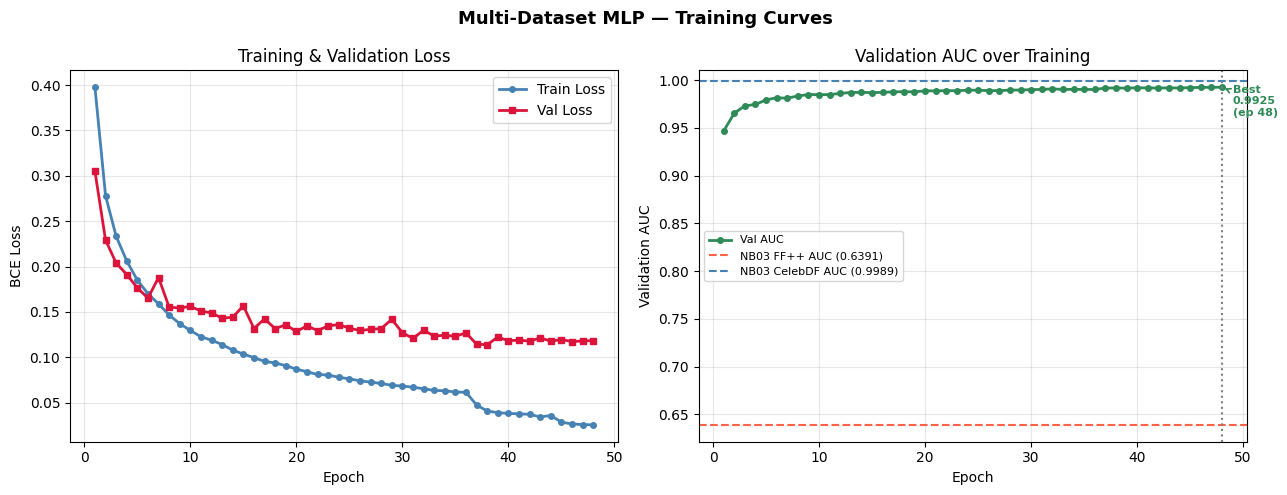

  ✓  Saved → /data/mpstme-naman/deepfake_detection/results/mlp_multi_training_curve.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Multi-Dataset MLP — Training Curves', fontsize=13, fontweight='bold')

history = mlp_multi.history
epochs = range(1, len(history['train_loss']) + 1)

# Left: Loss
ax = axes[0]
ax.plot(epochs, history['train_loss'], 'o-', color='steelblue', lw=2, ms=4, label='Train Loss')
ax.plot(epochs, history['val_loss'],   's-', color='crimson',   lw=2, ms=4, label='Val Loss')
ax.set_xlabel('Epoch'); ax.set_ylabel('BCE Loss')
ax.set_title('Training & Validation Loss')
ax.legend(); ax.grid(alpha=0.3)

# Right: Val AUC
ax = axes[1]
ax.plot(epochs, history['val_auc'], 'o-', color='seagreen', lw=2, ms=4, label='Val AUC')
ax.axhline(0.6391, color='tomato',    ls='--', lw=1.5, label='NB03 FF++ AUC (0.6391)')
ax.axhline(0.9989, color='steelblue', ls='--', lw=1.5, label='NB03 CelebDF AUC (0.9989)')
best_epoch = int(np.argmax(history['val_auc'])) + 1
best_auc   = float(max(history['val_auc']))
ax.axvline(best_epoch, color='gray', ls=':', lw=1.5)
ax.annotate(f'Best\n{best_auc:.4f}\n(ep {best_epoch})',
            xy=(best_epoch, best_auc), xytext=(best_epoch + 1, best_auc - 0.03),
            fontsize=8, color='seagreen', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='seagreen', lw=1.2))
ax.set_xlabel('Epoch'); ax.set_ylabel('Validation AUC')
ax.set_title('Validation AUC over Training')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
out = RES_DIR / 'mlp_multi_training_curve.png'
plt.savefig(out, dpi=120, bbox_inches='tight')
plt.show()
print(f'  ✓  Saved → {out}')

## Summary & Verification

In [11]:
# ── Manual verification checklist ────────────────────────────────────────
import os

print('=' * 62)
print('  Multi-Dataset Training — Verification Checklist')
print('=' * 62)
print()

# 1. Dataset size
ok1 = (len(y_multi) == 222184)
print(f'  [{"PASS" if ok1 else "WARN"}] Combined size = {len(y_multi):,}'
      f'  (expected ~222,184)')

# 2. Checkpoint saved
ckpt_path = str(CKPT_DIR / 'mlp_multi_best.pt')  # <-- ADD THIS LINE
ckpt_exists = os.path.exists(ckpt_path)
print(f'  [{"PASS" if ckpt_exists else "FAIL"}] Checkpoint mlp_multi_best.pt'
      f'  ({os.path.getsize(ckpt_path)/1e6:.1f} MB)' if ckpt_exists else
      f'  [FAIL] Checkpoint NOT FOUND: {ckpt_path}')

# 3. Val AUC improved
best_val = float(max(history['val_auc']))
ok3 = best_val > 0.70
print(f'  [{"PASS" if ok3 else "FAIL"}] Best val AUC = {best_val:.4f}'
      f'  (expected > 0.70 for meaningful multi-domain training)')

# 4. Training curve saved
curve_path = RES_DIR / 'mlp_multi_training_curve.png'
ok4 = curve_path.exists()
print(f'  [{"PASS" if ok4 else "FAIL"}] Training curve PNG saved')

# 5. No catastrophic overfitting (train_loss[-1] not >> val_loss[-1])
gap = history['train_loss'][-1] - history['val_loss'][-1]
ok5 = gap < 0.1
print(f'  [{"PASS" if ok5 else "WARN"}] Overfitting gap (train-val loss) = {gap:+.4f}'
      f'  (warn if > 0.10)')

print()
print('  Results summary:')
print(f'    CelebDF AUC   : {m_cd["auc"]:.4f}  (baseline 0.9989)')
print(f'    FF++ AUC      : {m_ff["auc"]:.4f}  (baseline 0.6391)')
print(f'    SD detection  : {sd_det:.1f}%   (baseline 0.6%)')
print()
print(f'    Checkpoint    : {ckpt_path}')
print(f'    Training plot : {curve_path}')
print()
print('  Next: Run 10_robust_envelope.ipynb')

  Multi-Dataset Training — Verification Checklist

  [PASS] Combined size = 222,184  (expected ~222,184)
  [PASS] Checkpoint mlp_multi_best.pt  (3.2 MB)
  [PASS] Best val AUC = 0.9925  (expected > 0.70 for meaningful multi-domain training)
  [PASS] Training curve PNG saved
  [PASS] Overfitting gap (train-val loss) = -0.0928  (warn if > 0.10)

  Results summary:
    CelebDF AUC   : 0.9995  (baseline 0.9989)
    FF++ AUC      : 0.9968  (baseline 0.6391)
    SD detection  : 100.0%   (baseline 0.6%)

    Checkpoint    : /data/mpstme-naman/deepfake_detection/checkpoints/mlp_multi_best.pt
    Training plot : /data/mpstme-naman/deepfake_detection/results/mlp_multi_training_curve.png

  Next: Run 10_robust_envelope.ipynb
